In [2]:
# ============================ Simple Linear Regression ============================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv("data.csv", sep=';')

# One Feature
x = df[['Starting (USD)']]

# Target
y = df['Ending (USD)']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=0
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Predicted Values:")
print(y_pred)



Predicted Values:
[15760.6557377  16088.52459016 16088.52459016]


In [3]:
# Predicting each Y value
df['Pred Y']=model.predict(x)
df.head()

,Date,Starting (USD),Ending (USD),Pred Y
0,01.01.24,16800,16500,16498.360656
1,01.12.23,15900,16100,15760.655738
2,01.11.23,15800,15300,15678.688525
3,01.10.23,16100,16200,15924.590164
4,01.09.23,16300,15700,16088.524590


In [4]:
# y = mx + c

# m is the slope
# c is the y-intercept
# x is the independent variable
# y is the dependent variable

m = model.coef_
c = model.intercept_

print(f"m = {m}")
print(f"c = {c}")

m = [0.81967213]
c = 2727.8688524590198


In [5]:
print(m * 16700 + c)

[16416.39344262]


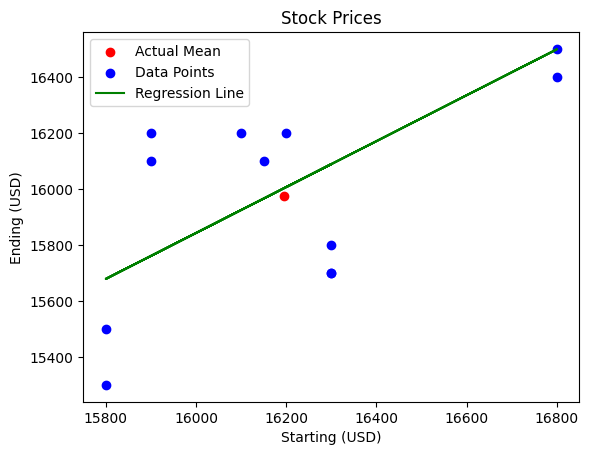

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np  
plt.scatter(df['Starting (USD)'].mean(), df['Ending (USD)'].mean(), color='red', label='Actual Mean')
plt.scatter(df['Starting (USD)'] , df['Ending (USD)'], color='blue', label='Data Points')
plt.plot(x, model.predict(x), color='green', label='Regression Line')
plt.xlabel('Starting (USD)')
plt.ylabel('Ending (USD)')
plt.title('Stock Prices')
plt.legend()
plt.show()

In [7]:
# ==================================== Lose And Cost ====================================
df['Lose'] = df['Ending (USD)'] - df['Pred Y']
# df['Cost'] = df['Lose'] ** 2
df


,Date,Starting (USD),Ending (USD),Pred Y,Lose
0,01.01.24,16800,16500,16498.360656,1.639344
1,01.12.23,15900,16100,15760.655738,339.344262
2,01.11.23,15800,15300,15678.688525,-378.688525
3,01.10.23,16100,16200,15924.590164,275.409836
4,01.09.23,16300,15700,16088.524590,-388.524590
5,01.08.23,16800,16400,16498.360656,-98.360656
6,01.07.23,15900,16200,15760.655738,439.344262
7,01.06.23,15800,15500,15678.688525,-178.688525
8,01.05.23,16150,16100,15965.573770,134.426230
9,01.04.23,16300,15800,16088.524590,-288.524590


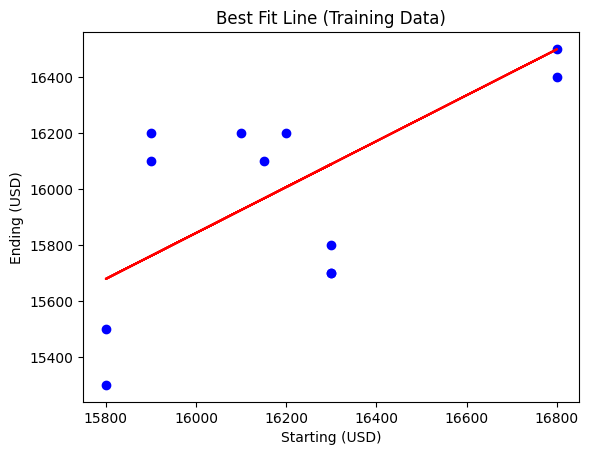

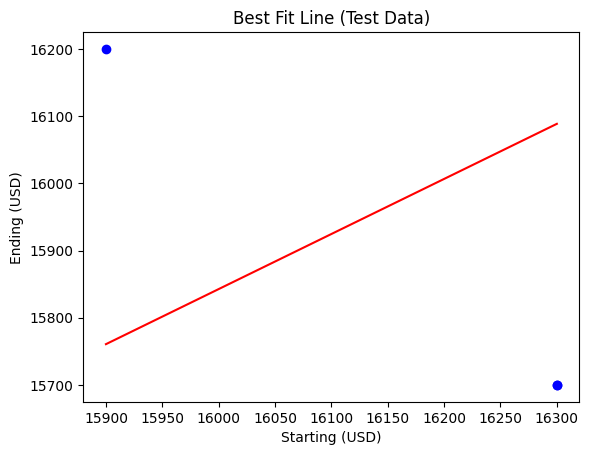

In [9]:
# Best Fit Line

plt.scatter(df['Starting (USD)'], df['Ending (USD)'], color='blue')

plt.plot(df['Starting (USD)'], model.predict(df[['Starting (USD)']]), color='red')

plt.title("Best Fit Line (Training Data)")
plt.xlabel("Starting (USD)")
plt.ylabel("Ending (USD)")
plt.show()

plt.scatter(X_test, y_test, color='blue')

plt.plot(X_test, model.predict(X_test), color='red')

plt.title("Best Fit Line (Test Data)")
plt.xlabel("Starting (USD)")
plt.ylabel("Ending (USD)")
plt.show()